1. Importar librerías de ML Avanzado

Predicción de Ventas (Forecasting), vamos a construir modelos de Machine Learning capaces de predecir el futuro. Esto no es magia, son matemáticas puras.

A diferencia de la segmentación (que agrupa datos actuales), aquí trabajaremos con Series de Tiempo. La regla de oro en series de tiempo es: NUNCA mezclamos los datos aleatoriamente. Tenemos que entrenar al modelo con el pasado para que intente predecir el futuro.

Probaremos tres algoritmos: Regresión Lineal (nuestra base), Random Forest, y el rey de las competencias de datos: XGBoost.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")

# Conexión a la BD
load_dotenv('../.env')
engine = create_engine(f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}")

print("✅ Librerías de predicción cargadas.")

C:\Users\Andres\AppData\Local\Temp\ipykernel_20988\351700036.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Librerías de predicción cargadas.


2. Extraer y agrupar las ventas por día

Para predecir, necesitamos la suma de ingresos diarios en orden cronológico

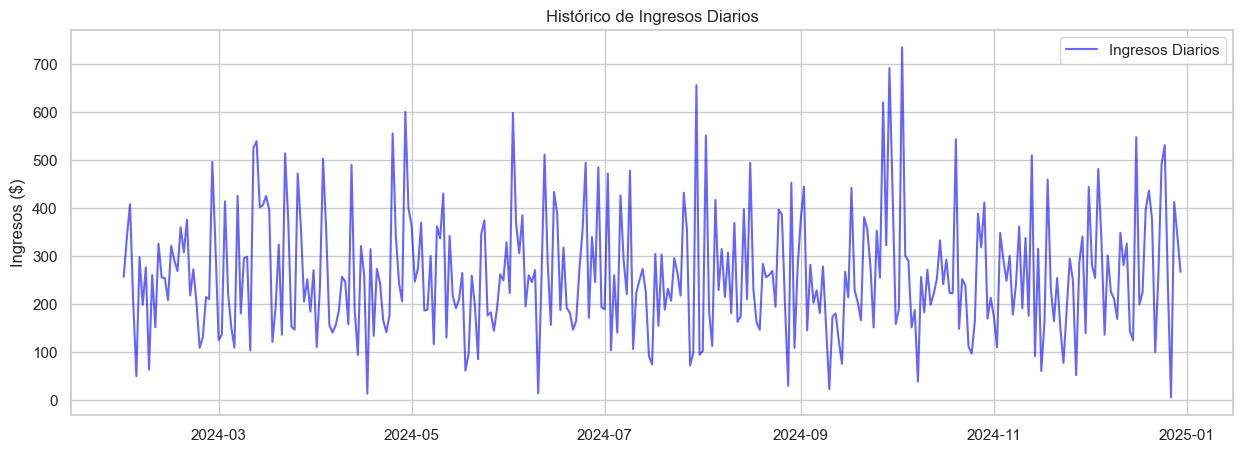

In [2]:
query = """
SELECT 
    DATE(v.fecha) as fecha,
    SUM(v.cantidad * p.precio_unitario) as ingresos_diarios
FROM ventas v
JOIN productos p ON v.id_producto = p.id_producto
WHERE v.estado = 'Completa'
GROUP BY DATE(v.fecha)
ORDER BY fecha ASC;
"""

df_ventas = pd.read_sql(query, engine)
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])
df_ventas.set_index('fecha', inplace=True)

# Llenar días sin ventas con 0 (si los hay)
df_ventas = df_ventas.asfreq('D', fill_value=0)

plt.figure(figsize=(15, 5))
plt.plot(df_ventas.index, df_ventas['ingresos_diarios'], label='Ingresos Diarios', color='blue', alpha=0.6)
plt.title('Histórico de Ingresos Diarios')
plt.ylabel('Ingresos ($)')
plt.legend()
plt.show()

3. Feature Engineering (Ingeniería de Características)

Un modelo de ML no entiende las fechas mágicamente. Tenemos que extraer el "Día de la semana" y crear "Lags" (retrasos) para decirle al modelo: "Oye, las ventas de hoy dependen mucho de las ventas de hace 1 día y de hace 7 días".

In [3]:
# Crear variables temporales
df_features = df_ventas.copy()
df_features['dia_semana'] = df_features.index.dayofweek
df_features['mes'] = df_features.index.month

# Crear Lags (ventas de los días anteriores)
df_features['ventas_ayer'] = df_features['ingresos_diarios'].shift(1)
df_features['ventas_hace_7_dias'] = df_features['ingresos_diarios'].shift(7)

# Promedio móvil de los últimos 7 días
df_features['promedio_7_dias'] = df_features['ingresos_diarios'].rolling(window=7).mean().shift(1)

# Eliminar las primeras filas que quedaron con valores nulos (NaNs) por culpa del shift()
df_features = df_features.dropna()

df_features.head()

,ingresos_diarios,dia_semana,mes,ventas_ayer,ventas_hace_7_dias,promedio_7_dias
fecha,,,,,,
2024-02-07,275.68,2,2,197.65,255.98,249.851429
2024-02-08,62.89,3,2,275.68,338.55,252.665714
2024-02-09,259.51,4,2,62.89,407.56,213.285714
2024-02-10,151.05,5,2,259.51,203.08,192.135714
2024-02-11,324.82,6,2,151.05,49.13,184.702857


4. Train / Test Split (División Temporal)

Vamos a separar los últimos 30 días para poner a prueba nuestro modelo. Entrenará con todo el historial previo, y le pediremos que prediga esos últimos 30 días para ver si acierta.

In [4]:
# Separar variables predictoras (X) de lo que queremos predecir (y)
X = df_features.drop(columns=['ingresos_diarios'])
y = df_features['ingresos_diarios']

# Usaremos los últimos 30 días como Test
dias_test = 30
X_train, X_test = X.iloc[:-dias_test], X.iloc[-dias_test:]
y_train, y_test = y.iloc[:-dias_test], y.iloc[-dias_test:]

print(f"Días para entrenar: {len(X_train)}")
print(f"Días para predecir (Test): {len(X_test)}")

Días para entrenar: 298
Días para predecir (Test): 30


5. Entrenamiento y Evaluación de Modelos

In [5]:
# Inicializar modelos
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

resultados = {}
predicciones = {}

# Entrenar y evaluar cada modelo
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    preds = modelo.predict(X_test)
    predicciones[nombre] = preds
    
    # Métricas
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    resultados[nombre] = {'MAE': mae, 'RMSE': rmse}

# Mostrar resultados
df_resultados = pd.DataFrame(resultados).T
display(df_resultados.sort_values(by='MAE'))

,MAE,RMSE
Regresión Lineal,112.895797,141.801081
Random Forest,128.386667,159.337495
XGBoost,149.350509,190.999399


Nota de negocio: El MAE significa "Error Absoluto Medio". Si te sale un MAE de 50, significa que en promedio, las predicciones del modelo se equivocaron por $50 (por arriba o por abajo). El modelo con el MAE más bajo es el ganador.

6. Visualizar las Predicciones vs la Realidad

Vamos a graficar qué tan bien el mejor modelo (digamos, XGBoost) logró predecir los últimos 30 días comparado con lo que realmente pasó.

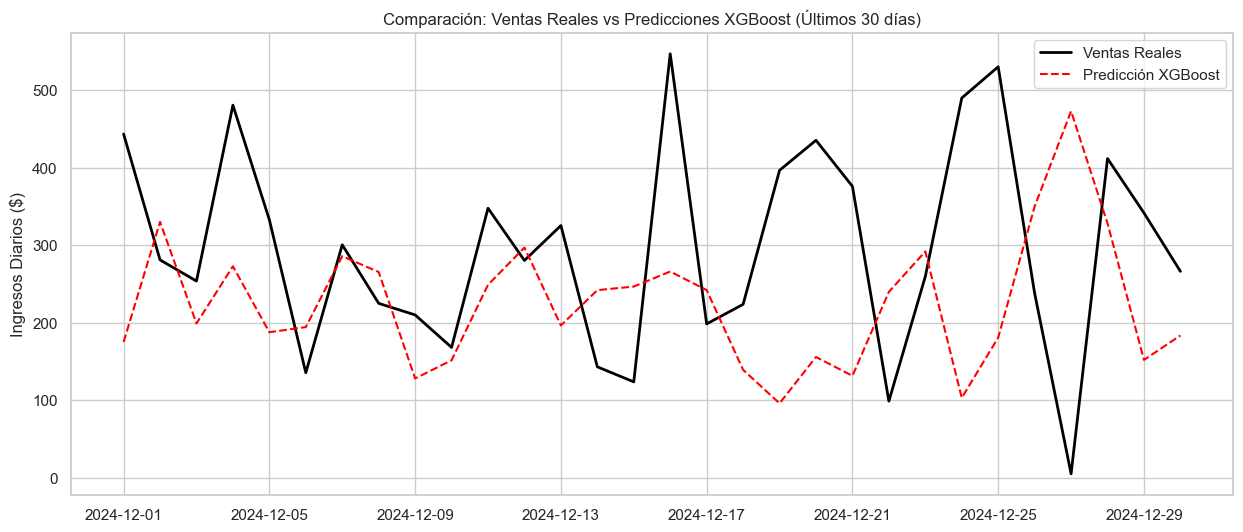

In [6]:
plt.figure(figsize=(15, 6))

# Graficamos la realidad
plt.plot(y_test.index, y_test.values, label='Ventas Reales', color='black', linewidth=2)

# Graficamos las predicciones de XGBoost
plt.plot(y_test.index, predicciones['XGBoost'], label='Predicción XGBoost', color='red', linestyle='--')

plt.title('Comparación: Ventas Reales vs Predicciones XGBoost (Últimos 30 días)')
plt.ylabel('Ingresos Diarios ($)')
plt.legend()
plt.show()

7. Guardar las predicciones en PostgreSQL

Vamos a guardar los resultados del modelo XGBoost en la base de datos para consumirlos luego desde Power BI.

In [7]:
# Preparar DataFrame con los resultados
df_export = pd.DataFrame({
    'fecha': y_test.index,
    'ventas_reales': y_test.values,
    'ventas_predichas': np.round(predicciones['XGBoost'], 2)
})

print("📤 Guardando predicciones en PostgreSQL...")
try:
    df_export.to_sql('predicciones_ventas', engine, if_exists='replace', index=False)
    
    with engine.connect() as con:
        con.execute(text("GRANT SELECT ON predicciones_ventas TO andes_user;"))
        con.commit()
        
    print("✅ ¡Predicciones guardadas con éxito en la tabla 'predicciones_ventas'!")
except Exception as e:
    print(f"❌ Error: {e}")

📤 Guardando predicciones en PostgreSQL...
✅ ¡Predicciones guardadas con éxito en la tabla 'predicciones_ventas'!
